In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Подберите параметры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.

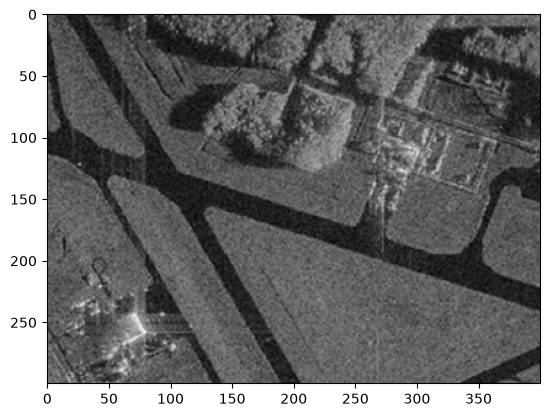

In [25]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

In [29]:
import math
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])                                                       
    if abs(av_val - img[point]) <= T:
        return True
    return False

def region_growing(image, seed_point,homo_fun,r, T):
    mask = np.zeros(image_gray.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image_gray.shape, np.uint8)
        for i in range(r,image.shape[0] - r):
            for j in range(r,image.shape[1] - r):
                if mask[i,j]==0 and mask[i - r:i + r, j-r: j+r].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        print(count)
        mask += local_mask
    return mask*255

seed_point = (250,250)
mask = region_growing(image_gray,seed_point,homo_average, 7, 20)

184
525
845
1190
1515
1842
1517
1581
1467
1339
1228
1137
1103
1273
1338
1495
1474
1614
1903
1769
1509
1580
1521
1617
1720
2378
2181
1960
1465
1577
1482
1521
1784
1678
1619
1753
2392
1813
1649
1813
1523
465
384
393
456
497
490
469
402
534
632
650
434
343
341
379
397
366
234
108
68
11
0


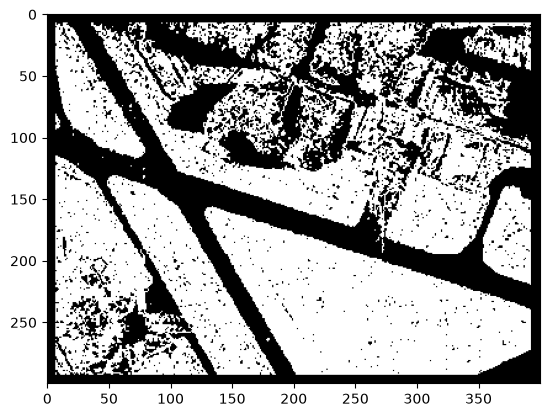

In [30]:
plt.imshow(mask, cmap="gray")

# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.

184
529
846
1196
1509
1844
1549
1554
1467
1340
1276
1144
1109
1214
1344
1495
1590
1633
1774
1776
1677
1598
1549
1639
1747
2132
2193
2287
1487
1606
1513
1549
1808
1708
1648
1795
1855
1829
1665
1825
1547
468
386
393
457
1228
512
581
608
647
569
495
403
352
357
394
380
304
229
94
70
12
0


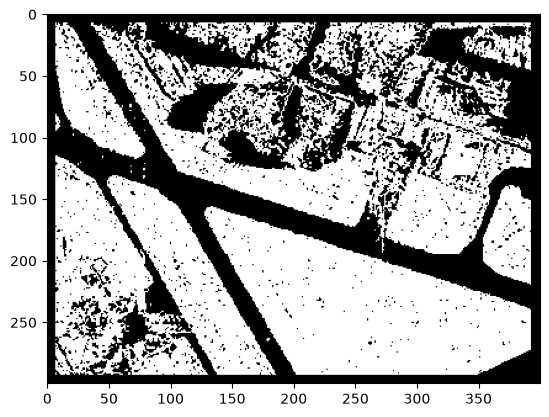

In [31]:
def homo_median(img, mask, point, T):
    median = np.median(img[mask > 0])
    return abs(median - img[point]) <= T

mask_median = region_growing(image_gray,seed_point,homo_median,7, 20)
plt.imshow(mask_median, cmap="gray")

In [34]:
from skimage.metrics import structural_similarity, mean_squared_error

mse_average = mean_squared_error(image_gray, mask)
mse_median = mean_squared_error(image_gray, mask_median)

(ssim_average, diff) = structural_similarity(image_gray,  mask, full=True)
(ssim_median, diff) = structural_similarity(image_gray,  mask_median, full=True)

print(mse_average, ssim_average)
print(mse_median, ssim_median)

16704.385708333335 0.11708368113506008
16877.067458333335 0.1238328432524856


# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

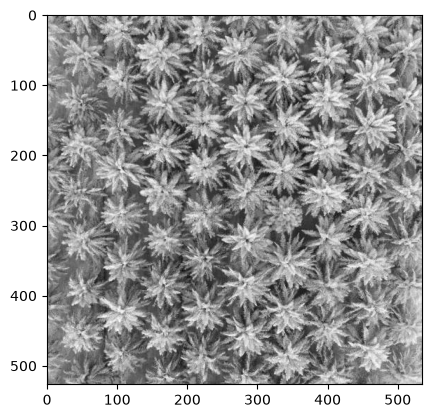

In [35]:
image = cv2.imread('palm_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

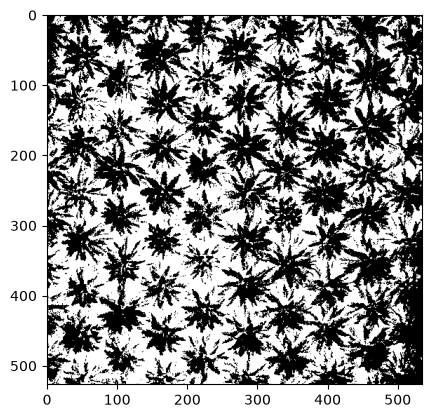

In [36]:
ret, thresh = cv2.threshold(image_gray,0,255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
plt.imshow(thresh, cmap="gray")

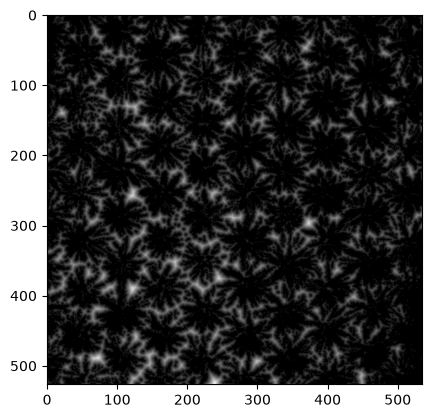

In [37]:
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5) 
plt.imshow(dist, cmap="gray")

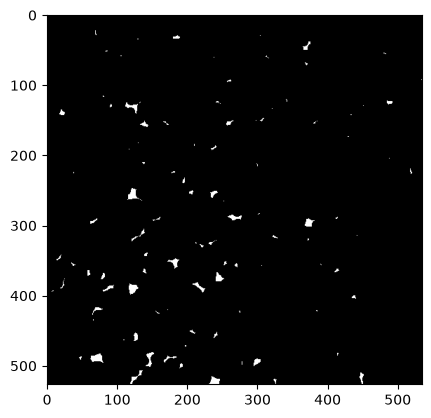

In [38]:
ret, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, cv2.THRESH_BINARY)
plt.imshow(sure_fg, cmap="gray")

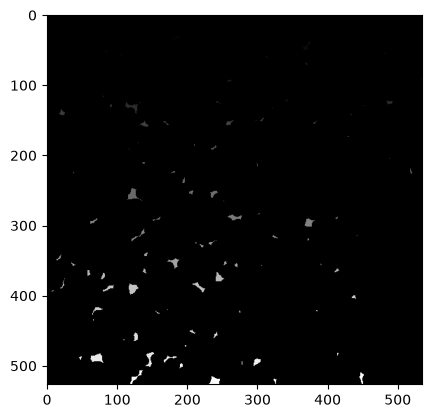

In [39]:
sure_fg = sure_fg.astype(np.uint8)
ret, markers = cv2.connectedComponents(sure_fg)
plt.imshow(markers, cmap="gray")

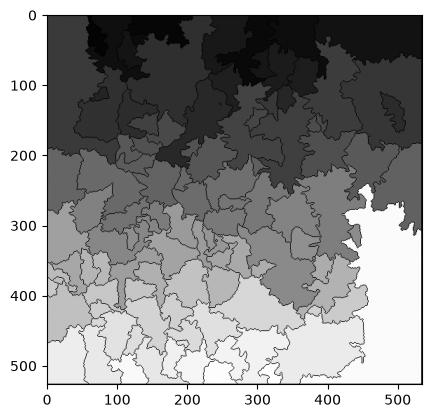

In [40]:
markers = cv2.watershed(image, markers)
plt.imshow(markers, cmap="gray")

In [41]:
palm_count = len(np.unique(markers)) - 1
print(f"Количество пальмовых деревьев: {palm_count}")

Количество пальмовых деревьев: 111
